In [2]:
import pandas as pd
import numpy as np
import ast
import json
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer



d:\FYP\29-3-25\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../../data/test-final/master_dataset_for_training.csv')
print("Dataset loaded. Total records:", len(df))


Dataset loaded. Total records: 301


In [4]:
def parse_segments(segments_str):
    if not isinstance(segments_str, str):
        return segments_str
    try:
        return json.loads(segments_str)
    except Exception:
        try:
            return ast.literal_eval(segments_str)
        except Exception as e:
            print("Error parsing segments:", e)
            return []

def concatenate_candidate_text(segments_str):
    segments = parse_segments(segments_str)
    candidate_texts = [seg.get("text", "") for seg in segments if seg.get("speaker", "").lower() == "candidate"]
    return " ".join(candidate_texts)

df['full_transcript_text'] = df['segments'].apply(concatenate_candidate_text)
print("Sample concatenated transcript text:")
print(df['full_transcript_text'].iloc[0][:300])

Sample concatenated transcript text:
good morning raj sounds great im excited learn role share experience course ive working fintech space 6 years current role asiacredit lead team develops deploys machine learning models credit risk assessment weve built several models using lightgbm xgboost predict customer churn default probability 


In [5]:
text_model = SentenceTransformer('all-MiniLM-L6-v2')
df['text_embedding'] = df['full_transcript_text'].apply(lambda x: text_model.encode(x, show_progress_bar=False))


In [6]:
X_text = np.vstack(df['text_embedding'].values)
df['Overall_Score'] = df['Overall_Score'].astype(float)
y = df['Overall_Score'].values

print("Feature matrix shape:", X_text.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (301, 384)
Target vector shape: (301,)


In [7]:
X_text = np.vstack(df['text_embedding'].values)
df['Overall_Score'] = df['Overall_Score'].astype(float)
y = df['Overall_Score'].values

print("Feature matrix shape:", X_text.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (301, 384)
Target vector shape: (301,)


In [8]:
# Step 4: Split Data
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.3, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (210, 384)
Test set shape: (91, 384)


In [9]:
ridge_model = Ridge(alpha=1.0)  # You can tune the alpha parameter
ridge_model.fit(X_train, y_train)

Ridge()

In [10]:
y_train_pred = ridge_model.predict(X_train)
y_test_pred = ridge_model.predict(X_test)


In [11]:
# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [12]:
# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [13]:
print("Ridge Regression Baseline Performance:")
print(f"Train RMSE: {train_rmse:.3f}, Train R²: {train_r2:.3f}")
print(f"Test RMSE: {test_rmse:.3f}, Test R²: {test_r2:.3f}")

Ridge Regression Baseline Performance:
Train RMSE: 0.061, Train R²: 0.922
Test RMSE: 0.076, Test R²: 0.855


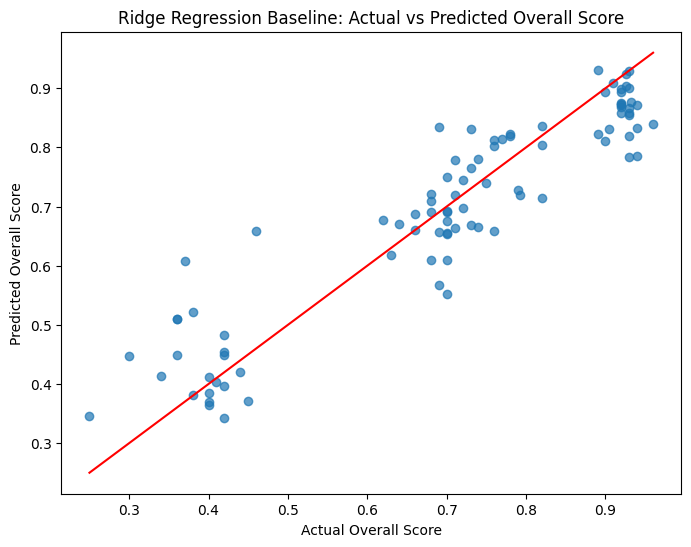

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Ridge Regression Baseline: Actual vs Predicted Overall Score")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line
plt.show()